In [1]:
import requests
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import time
import matplotlib.colors as mcolors
import astropy.units as u
import pandas as pd
import sympy as sp

from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.cosmology import FlatLambdaCDM
from pysr import PySRRegressor
from scipy.stats import binned_statistic_dd
from sklearn.metrics import mean_squared_error, median_absolute_error
from scipy.optimize import curve_fit
from sklearn.mixture import GaussianMixture
from scipy.stats import norm


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Get function for downloads and API reading

In [2]:
# define function to get data from api and downloads
baseURL = 'http://www.tng-project.org/api/'
headers = {"api-key": "96ec8ab7a20d9b1666d6f0a5a4a8e0b9"}

def get(path, local_filename=None, params=None, max_retries=5):
    if local_filename and os.path.exists(local_filename):
        print(f"File {local_filename} already exists. Skipping network request.")
        return local_filename

    url = path if path.startswith('http') else baseURL + path

    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, headers=headers, stream=True)
            r.raise_for_status()

            if 'application/json' in r.headers.get('content-type', ''):
                return r.json()

            if not local_filename:
                if 'content-disposition' in r.headers:
                    local_filename = r.headers['content-disposition'].split("filename=")[1]
                else:
                    local_filename = url.split('/')[-1] if url.split('/')[-1] else 'downloaded_tng_file'

            if os.path.exists(local_filename):
                print(f"File {local_filename} derived from header already exists. Skipping save.")
                return local_filename

            # disk stream download routine with live visual readout
            total_size = int(r.headers.get('content-length', 0))
            block_size = 4 * 1024 * 1024  # 4 mb chunks
            
            if total_size > 0:
                print(f"Downloading {local_filename} ({total_size / (1024**3):.2f} GB)...")
            else:
                print(f"Downloading {local_filename} (Unknown total file size)...")

            with open(local_filename, 'wb') as f:
                dl = 0
                start_time = time.time()
                for chunk in r.iter_content(chunk_size=block_size):
                    if chunk:
                        f.write(chunk)
                        dl += len(chunk)
                        
                        # status bar tracker
                        if total_size > 0:
                            done = int(50 * dl / total_size)
                            percent = (dl / total_size) * 100
                            elapsed = time.time() - start_time
                            speed = (dl / elapsed) / (1024**2) if elapsed > 0 else 0
                            print(f"\r[{'=' * done}{' ' * (50-done)}] {percent:.1f}% ({speed:.1f} MB/s)", end="")
                        else:
                            print(f"\rDownloaded: {dl / (1024**2):.1f} MB...", end="")
            print("\nDownload Complete!")
            return local_filename

        except requests.exceptions.HTTPError as e:
            # check for standard server-side rate limits or transient auth failures
            if r.status_code == 403 and attempt < max_retries - 1:
                wait_time = 2 ** attempt 
                print(f"\nAttempt {attempt+1} hit 403. Retrying in {wait_time}s...")
                time.sleep(wait_time)
                continue
            else:
                raise e

Extract and Prepare Data

In [3]:
# load data from files
snap = get("http://www.tng-project.org/api/TNG300-1/snapshots/")
tree_data = {'subhalos': {}}
with h5py.File(r"C:\Users\rizkw\Documents\LCP Research\Project Files\Reproducing Florine's Work\TNG300_1_data.hdf5","r") as f:
    subhalos_grp = f['subhalos']
    for key in subhalos_grp.keys():
        tree_data['subhalos'][key] = subhalos_grp[key][()]

with h5py.File(r"C:\Users\rizkw\Documents\LCP Research\Project Files\Reproducing Florine's Work\TNG-Cluster_data.hdf5",'r') as f:
    subhalos_grp = f['subhalos']
    for key in subhalos_grp.keys():
        new_data = subhalos_grp[key][()]
        existing_data = tree_data['subhalos'][key]
        tree_data['subhalos'][key] = np.concatenate((existing_data, new_data), axis=0)


In [4]:
# calculating lookback time

# this defines the constants we use in flat lambda CDM
cosmology = FlatLambdaCDM(H0=67.74, Om0=0.3089, Ob0=0.0486)

lookback_infall3 = cosmology.lookback_time(tree_data['subhalos']['infall_z3']).value
lookback_infall1 = cosmology.lookback_time(tree_data['subhalos']['infall_z1']).value
lookback_sub = cosmology.lookback_time(tree_data['subhalos']['z']).value

tree_data['subhalos']['lookback_time3'] = lookback_infall3 - lookback_sub

tree_data['subhalos']['lookback_time1'] = lookback_infall1 - lookback_sub


c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\astropy\cosmology\_src\flrw\lambdacdm.py:496: RuntimeWarning: invalid value encountered in divide
  np.emath.sqrt((1 / self.Om0 - 1 + 0j) / (aszarr(z) + 1.0) ** 3)
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_scimath_impl.py:120: RuntimeWarning: invalid value encountered in less
  if any(isreal(x) & (x < 0)):
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_scimath_impl.py:238: RuntimeWarning: invalid value encountered in sqrt
  return nx.sqrt(x)
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\astropy\cosmology\_src\flrw\lambdacdm.py:495: RuntimeWarning: invalid value encountered in arcsinh
  arg = np.arcsinh(


In [5]:
# recalculate 3d radius to filter out for 1 r200
tree_data['subhalos']['norm_r_3d'] = np.sqrt((tree_data['subhalos']['norm_r_xy']**2 + tree_data['subhalos']['norm_r_xz']**2 
                                              + tree_data['subhalos']['norm_r_yz']**2) / 2)

In [6]:
# store data in separate dicts for redshifts
r_axis = {}
v_axis = {}
infall_axis3 = {}
infall_axis1 = {}
stel = {}
vir = {}
log10stel = {}
log10vir = {}
steps = {}
z_inf = {}
infall_axis1_clean = {}
r_axis_clean = {}
v_axis_clean = {}
m_axis_clean = {}

snapshots = [99, 84, 78, 67, 59, 50]
redshifts = [2.22044604925031e-16, 0.19728418237601, 0.297717684517447, 0.503047523244883, 0.700106353718523, 0.99729422578194]
for snapshot in snapshots:
    snapRmask = (tree_data['subhalos']['snap'] == snapshot) & (tree_data['subhalos']['norm_r_3d'] <= 1.0)
    r_axis[snapshot] = []
    v_axis[snapshot] = []
    infall_axis3[snapshot] = []
    infall_axis1[snapshot] = []
    stel[snapshot] = []
    vir[snapshot] = []
    log10stel[snapshot] = []
    log10vir[snapshot] = []
    steps[snapshot] = []
    z_inf[snapshot] = []

    r_axis[snapshot].append(tree_data['subhalos']['norm_r_xy'][snapRmask])
    r_axis[snapshot].append(tree_data['subhalos']['norm_r_xz'][snapRmask])
    r_axis[snapshot].append(tree_data['subhalos']['norm_r_yz'][snapRmask])
    v_axis[snapshot].append(tree_data['subhalos']['norm_v_z'][snapRmask])
    v_axis[snapshot].append(tree_data['subhalos']['norm_v_y'][snapRmask])
    v_axis[snapshot].append(tree_data['subhalos']['norm_v_x'][snapRmask])
    infall_axis3[snapshot].append(tree_data['subhalos']['lookback_time3'][snapRmask])
    infall_axis3[snapshot].append(tree_data['subhalos']['lookback_time3'][snapRmask])
    infall_axis3[snapshot].append(tree_data['subhalos']['lookback_time3'][snapRmask])
    infall_axis1[snapshot].append(tree_data['subhalos']['lookback_time1'][snapRmask])
    infall_axis1[snapshot].append(tree_data['subhalos']['lookback_time1'][snapRmask])
    infall_axis1[snapshot].append(tree_data['subhalos']['lookback_time1'][snapRmask])
    stel[snapshot].append(tree_data['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
    stel[snapshot].append(tree_data['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
    stel[snapshot].append(tree_data['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
    vir[snapshot].append(tree_data['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
    vir[snapshot].append(tree_data['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
    vir[snapshot].append(tree_data['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
    steps[snapshot].append(tree_data['subhalos']['step_counts3'][snapRmask])
    steps[snapshot].append(tree_data['subhalos']['step_counts3'][snapRmask])
    steps[snapshot].append(tree_data['subhalos']['step_counts3'][snapRmask])
    z_inf[snapshot].append(tree_data['subhalos']['infall_z3'][snapRmask])
    z_inf[snapshot].append(tree_data['subhalos']['infall_z3'][snapRmask])
    z_inf[snapshot].append(tree_data['subhalos']['infall_z3'][snapRmask])
    r_axis[snapshot] = np.concatenate(r_axis[snapshot])
    v_axis[snapshot] = np.concatenate(v_axis[snapshot])
    infall_axis3[snapshot] = np.concatenate(infall_axis3[snapshot])
    infall_axis1[snapshot] = np.concatenate(infall_axis1[snapshot])
    log10stel[snapshot] = np.log10(np.concatenate(stel[snapshot]))
    log10vir[snapshot] = np.log10(np.concatenate(vir[snapshot]))
    steps[snapshot] = np.concatenate(steps[snapshot])
    z_inf[snapshot] = np.concatenate(z_inf[snapshot])

    # filter nans
    valid = ~np.isnan(infall_axis1[snapshot])
    infall_axis1_clean[snapshot] = infall_axis1[snapshot][valid]
    r_axis_clean[snapshot] = r_axis[snapshot][valid]
    v_axis_clean[snapshot] = v_axis[snapshot][valid]
    m_axis_clean[snapshot] = log10stel[snapshot][valid]

Binning the data (r<=1 only)

In [7]:
# ALL BINNING CODE
X_binned = {}
y_mean = {}
y_q1 = {}
y_med = {}
y_q3 = {}

for snapshot in snapshots:
    # prepare all raw inputs as a matrix with columns of each input
    X_clean = np.column_stack((r_axis_clean[snapshot], np.abs(v_axis_clean[snapshot]), m_axis_clean[snapshot])) #, log10vir[snapshot]))
    y_clean = infall_axis1_clean[snapshot]

    # X_clean[np.isinf(X_raw)] = np.nan

    # clean_rows = ~np.isnan(X_raw).any(axis=1) & ~np.isnan(y_raw)

    # X_clean = X_raw[clean_rows]
    # y_clean = y_raw[clean_rows]
    # create percentile bins

    r_edges = np.percentile(X_clean[:,0], np.linspace(0, 100, 12))
    v_edges = np.percentile(X_clean[:,1], np.linspace(0, 100, 12))
    m_edges = np.percentile(X_clean[:,2], np.linspace(0, 100, 9))
    # vir_edges = np.percentile(X_clean[:,3], np.linspace(0, 100, 5))

    quartile_bins = [r_edges, v_edges, m_edges] #, vir_edges]
    # sort data into bins

    # compute num of galaxies in each bin
    counts, _, _ = binned_statistic_dd(
        X_clean, values=None, statistic='count', bins=quartile_bins
    )

    # mask for only filled bins
    filled = np.where(counts > 0)
    Ngal_per = counts[filled]
    weights = np.log10(Ngal_per + 10)

    # extract mean features for grid size
    binned = []
    for i in range(X_clean.shape[1]):
        means, _, _ = binned_statistic_dd(X_clean, values=X_clean[:,i], statistic='mean', bins=quartile_bins)
        binned.append(means[filled])
    X_binned[snapshot] = np.column_stack(binned)

    mean_y, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic='mean', bins=quartile_bins)
    y_mean[snapshot] = mean_y[filled]

    q1_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 25), bins=quartile_bins)
    y_q1[snapshot] = q1_y_grid[filled]

    q2_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 50), bins=quartile_bins)
    y_med[snapshot] = q2_y_grid[filled]

    q3_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 75), bins=quartile_bins)
    y_q3[snapshot] = q3_y_grid[filled]

    print(f"Num of binned data points for PySR: {len(y_mean[snapshot])}")
    # mask for valid entries in bins
    mean_mask = ~np.isnan(y_mean[snapshot]) & (y_mean[snapshot] > 0)
    q1_mask = ~np.isnan(y_q1[snapshot]) & (y_q1[snapshot] > 0)
    med_mask = ~np.isnan(y_med[snapshot]) & (y_med[snapshot] > 0)
    q3_mask = ~np.isnan(y_q3[snapshot]) & (y_q3[snapshot] > 0)

    y_mean[snapshot] = y_mean[snapshot][mean_mask]
    y_q1[snapshot] = y_q1[snapshot][q1_mask]
    y_med[snapshot] = y_med[snapshot][med_mask]
    y_q3[snapshot] = y_q3[snapshot][q3_mask]

    # use if want to fit in log M* or log 10^10 M*
    # X_binned[snapshot][:,2] = X_binned[snapshot][:,2]-10
    # X_binned[snapshot][:,3] = X_binned[snapshot][:,3]-10

Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968


In [8]:
def eqn1noMPlot(Xvect, z): # from withMvir
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    a = 0.3113*z**2 + -0.9935*z + 2.6042

    return np.maximum(0,-v + (a - r)**2)

def eqn2noMPlot(Xvect, z): # from noMvir_m10
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    a = 0.6714*z**2 + -1.8517*z + 3.5743
    b = 0.2315*z + 0.4137

    return np.maximum(0,-v + a/(r + b))

def eqn3Plot(Xvect, z): # from noMvir_m10
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    a = 52.9937*z**2 + -94.8515*z + 49.4037
    b = 3.6983*z**2 + -8.7523*z + 9.0283

    return np.maximum(0,-v - np.sqrt(r*((logms-10) + a)) + b)

def eqn3_2Plot(Xvect, z): # from withMvir
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    a = -1.1092*z**2 + 2.5333*z + -2.2554
    b = 3.6838*z**2 + -8.7370*z + 9.0422

    return np.maximum(0,-v + a*np.sqrt(logms*r) + b)

def testz78Plot(Xvect, z):
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    a = -0.7026*z**2 + 1.4616*z + -1.0101
    b = 0.1121*z**2 + -0.3374*z + 0.4962
    c = -0.6824*z**2 + 1.9914*z + -3.1072
    return np.maximum(0, a*v + (b*np.sqrt(logms*r) + c)**2)
    # return np.maximum(0, (a*v**2 + b*np.sqrt(logms*r) + c)**2)


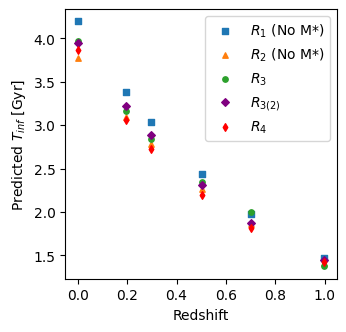

In [9]:
plt.figure(figsize=(3.5,3.5))

plot_redshifts = []
estimates1 = []
estimates2 = []
estimates3 = []
estimates3_2 = []
estimates4 = []

for i, snapshot in enumerate(snapshots):
    medianr = np.median(r_axis_clean[snapshot])
    medianv = np.median(v_axis_clean[snapshot])
    medianm = np.median(m_axis_clean[snapshot])
    Xvect = [medianr, medianv, medianm]

    predicted_T_1 = eqn1noMPlot(Xvect, redshifts[i])
    predicted_T_2 = eqn2noMPlot(Xvect, redshifts[i])
    predicted_T_3 = eqn3Plot(Xvect, redshifts[i])
    predicted_T_3_2 = eqn3_2Plot(Xvect, redshifts[i])
    predicted_T_4 = testz78Plot(Xvect, redshifts[i])
    plot_redshifts.append(redshifts[i])
    estimates1.append(predicted_T_1)
    estimates2.append(predicted_T_2)
    estimates3.append(predicted_T_3)
    estimates3_2.append(predicted_T_3_2)
    estimates4.append(predicted_T_4)

plt.scatter(redshifts, estimates1, marker='s', label='$R_1$ (No M*)', s=15)
plt.scatter(redshifts, estimates2, marker='^', label='$R_2$ (No M*)', s=15)
plt.scatter(redshifts, estimates3, marker='o', label='$R_3$', s=15)
plt.scatter(redshifts, estimates3_2, marker='D', label='$R_{3(2)}$', s=15, color='purple')
plt.scatter(redshifts, estimates4, marker='d', label='$R_4$', s=15, color='red')
plt.xlabel('Redshift')
plt.ylabel(r'Predicted $T_{inf}$ [Gyr]')
# plt.title("Predictions for Median Galaxy at Each Redshift", fontsize='10')
plt.legend()

RMSEs of Each Equation

In [10]:
rmse4 = []
for i, snapshot in enumerate(snapshots):
    redshift = redshifts[i]
    r_raw = r_axis_clean[snapshot]
    v_raw = np.abs(v_axis_clean[snapshot])
    m_raw = m_axis_clean[snapshot]
    y_clean = infall_axis1_clean[snapshot]
    
    X_clean = np.column_stack((r_raw, v_raw, m_raw))
    
    pred1 = eqn1noMPlot(X_clean.T, redshift)
    pred2 = eqn2noMPlot(X_clean.T, redshift)
    pred3 = eqn3Plot(X_clean.T, redshift)
    pred3_2 = eqn3_2Plot(X_clean.T, redshift)
    pred4 = testz78Plot(X_clean.T, redshift)

    rmse1 = np.sqrt(mean_squared_error(y_clean, pred1))
    rmse2 = np.sqrt(mean_squared_error(y_clean, pred2))
    rmse3 = np.sqrt(mean_squared_error(y_clean, pred3))
    rmse3_2 = np.sqrt(mean_squared_error(y_clean, pred3_2))
    rmse4.append(np.sqrt(mean_squared_error(y_clean, pred4)))

    print(f"RMSEs at redshift: {round(redshift,2)} | Mean infall time at this redshift: {np.mean((y_clean))}")
    print(f"    Eqn1: {round(rmse1,2)}\n    Eqn2: {round(rmse2,2)}\n    Eqn3: {round(rmse3,2)}\n    Eqn3_2: {round(rmse3_2,2)}\n    Eqn4: {round(rmse4[i],2)}")


RMSEs at redshift: 0.0 | Mean infall time at this redshift: 3.9046003853928077
    Eqn1: 2.68
    Eqn2: 2.62
    Eqn3: 2.61
    Eqn3_2: 2.61
    Eqn4: 2.61
RMSEs at redshift: 0.2 | Mean infall time at this redshift: 3.1142913742324234
    Eqn1: 2.09
    Eqn2: 2.06
    Eqn3: 2.05
    Eqn3_2: 2.05
    Eqn4: 2.04
RMSEs at redshift: 0.3 | Mean infall time at this redshift: 2.7796501982433095
    Eqn1: 1.87
    Eqn2: 1.85
    Eqn3: 1.84
    Eqn3_2: 1.84
    Eqn4: 1.82
RMSEs at redshift: 0.5 | Mean infall time at this redshift: 2.223347312248539
    Eqn1: 1.56
    Eqn2: 1.55
    Eqn3: 1.54
    Eqn3_2: 1.54
    Eqn4: 1.48
RMSEs at redshift: 0.7 | Mean infall time at this redshift: 1.8557969105284098
    Eqn1: 1.34
    Eqn2: 1.34
    Eqn3: 1.34
    Eqn3_2: 1.33
    Eqn4: 1.23
RMSEs at redshift: 1.0 | Mean infall time at this redshift: 1.4648316945440285
    Eqn1: 1.12
    Eqn2: 1.11
    Eqn3: 1.11
    Eqn3_2: 1.11
    Eqn4: 0.94


Comparison of Predicted vs Actual at Different Redshifts

Text(0.07, 0.5, 'Predicted $T_{inf,grid}$ [Gyr]')

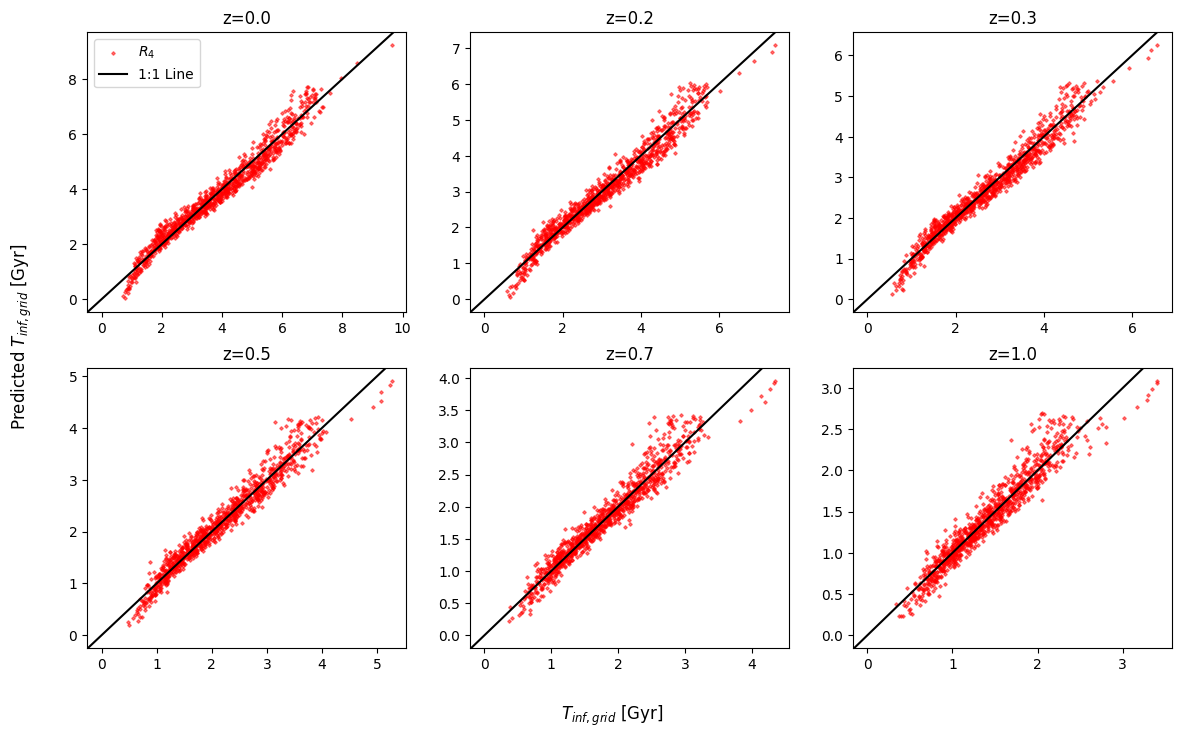

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))
plt.subplots_adjust(hspace=0.2, wspace=0.2)
ax = axes.flatten()

for i in range(6):
    snapshot = snapshots[i]
    # ax[i].scatter(y_mean[snapshot], eqn1noMPlot(X_binned[snapshot].T, redshifts[i]), label='R1 (No $M_*$)', marker='s', s=3)
    # ax[i].scatter(y_mean[snapshot], eqn2noMPlot(X_binned[snapshot].T, redshifts[i]), label='R2 (No $M_*$)', marker='^', s=3)
    # ax[i].scatter(y_mean[snapshot], eqn3Plot(X_binned[snapshot].T, redshifts[i]), label='R3', marker='o', s=3)
    # ax[i].scatter(y_mean[snapshot], eqn3_2Plot(X_binned[snapshot].T, redshifts[i]), label='R3_2', marker='D', s=3, color='purple', alpha=0.5)
    ax[i].scatter(y_mean[snapshot], testz78Plot(X_binned[snapshot].T, redshifts[i]), label='$R_4$', marker='D', s=3, color='red', alpha=0.5)
    ax[i].axline((0, 0), slope=1, color='black', label='1:1 Line')
    ax[i].set_title(f"z={round(redshifts[i],2)}")

ax[0].legend()

fig.supxlabel(r"$T_{inf,grid}$ [Gyr]")
fig.supylabel(r"Predicted $T_{inf,grid}$ [Gyr]", x=0.07)
# fig.suptitle(r"Predicted vs True Infall Time for $T_{inf}=Av + \left(B\sqrt{r\cdot\log_{10}(M_{\ast}/M_{\odot})} - C\right)^2$")


# plt.tight_layout()

RMSE Across PPS and z

In [12]:
def quadFit(redshift, A, B, C):
    z=redshift
    return A*z**2 + B*z + C

In [13]:
# fit eqn for RMSE across redshift
poptRMSE, pcovRMSE = curve_fit(quadFit, redshifts, rmse4, p0 = [1.0, 1.0, 1.0], nan_policy='omit')
print(f"Mean RMSE evolution with redshift: {round(poptRMSE[0],3)}z^2 + {round(poptRMSE[1],3)}z + {round(poptRMSE[2],3)}")

Mean RMSE evolution with redshift: 1.203z^2 + -2.826z + 2.583


In [14]:
# Florine's error values extracted from WebPlotDigitizer
rmseF = [2.308, 1.752, 1.555, 1.255, 1.052, 0.852]

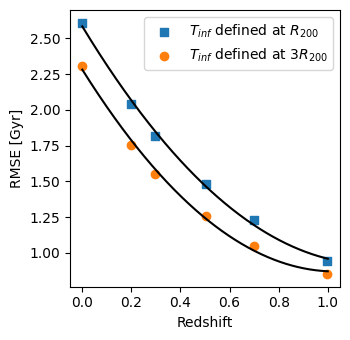

In [15]:
plt.figure(figsize=(3.6,3.5))
plt.scatter(redshifts, rmse4, marker='s', label='$T_{inf}$ defined at $R_{200}$')
plt.scatter(redshifts, rmseF, label='$T_{inf}$ defined at $3R_{200}$')
vals = np.linspace(0,1,300)
rmseEqn = poptRMSE[0]*vals**2 + poptRMSE[1]*vals + poptRMSE[2]
plt.plot(vals, rmseEqn, color='black') #, label=r"$1.202z^2 - 2.808z + 2.569$")
valsF = np.linspace(0,1,300)
rmseFEqn = 1.328*valsF**2 - 2.737*valsF + 2.281
plt.plot(valsF, rmseFEqn, color='black') #, label=r"$1.202z^2 - 2.808z + 2.569$")
plt.xlabel("Redshift")
plt.ylabel("RMSE [Gyr]")
# plt.title("Mean RMSE Evolution with Redshift", fontsize=10)
plt.legend()
plt.tight_layout()

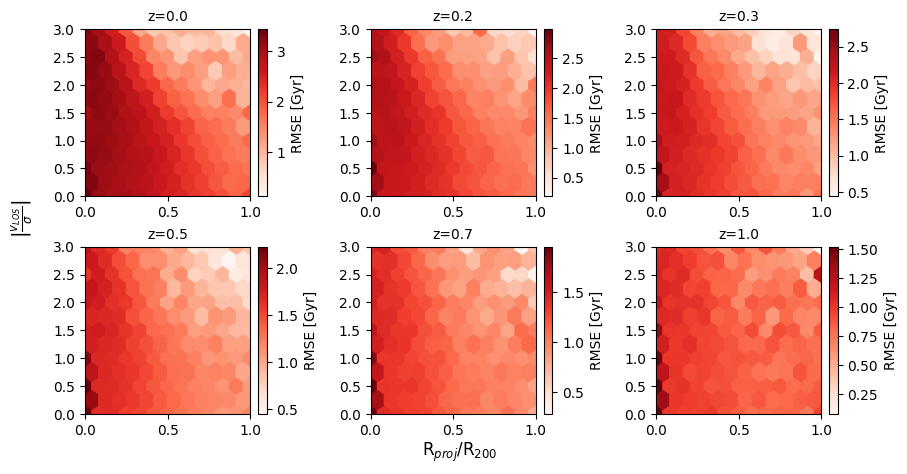

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(10,5))
plt.subplots_adjust(hspace=0.3, wspace=0.4)
ax = axes.flatten()
for i in range(6):
    snapshot = snapshots[i]
    redshift = redshifts[i]
    
    r_raw = r_axis_clean[snapshot]
    v_raw = np.abs(v_axis_clean[snapshot])
    m_raw = m_axis_clean[snapshot]
    y_clean = infall_axis1_clean[snapshot]
    
    X_clean = np.column_stack((r_raw, v_raw, m_raw))
    y_pred = testz78Plot(X_clean.T, redshift)
    r_plot = X_clean[:, 0]  
    v_plot = X_clean[:, 1]

    sq_errors = (y_clean - y_pred) ** 2

    ax[i].set_title(f"z={round(redshift,1)}", fontsize=10)
    hb = ax[i].hexbin(r_plot, v_plot, C=sq_errors, reduce_C_function=lambda cell: np.sqrt(np.mean(cell)), gridsize=12, extent=[0,1,0,3], cmap='Reds') # , vmin=0 , vmax=3.5)
    ax[i].set_xlim(0,1)
    ax[i].set_ylim(0,3)
    fig.colorbar(hb, ax=ax[i], pad=0.04, label='RMSE [Gyr]')

    
fig.supxlabel('R$_{proj}$/R$_{200}$') #, x=0.45, y=0.01)
fig.supylabel(r'$\left| \frac{v_{LOS}}{\sigma} \right|$', x=0.05)
# fig.suptitle('RMSE Estimates Across PPS at Different Redshifts') #, x=0.45)

# plt.tight_layout()
plt.show()

Comparison Between TNG300-1 and TNG-Cluster

In [17]:
tng300_data = {'subhalos': {}}
tngCluster_data = {'subhalos': {}}
with h5py.File(r"C:\Users\rizkw\Documents\LCP Research\Project Files\Reproducing Florine's Work\TNG300_1_data.hdf5","r") as f:
    subhalos_grp = f['subhalos']
    for key in subhalos_grp.keys():
        tng300_data['subhalos'][key] = subhalos_grp[key][()]

with h5py.File(r"C:\Users\rizkw\Documents\LCP Research\Project Files\Reproducing Florine's Work\TNG-Cluster_data.hdf5",'r') as f:
    subhalos_grp = f['subhalos']
    for key in subhalos_grp.keys():
        tngCluster_data['subhalos'][key] = subhalos_grp[key][()]

In [18]:
lookback_infall3 = cosmology.lookback_time(tng300_data['subhalos']['infall_z3']).value
lookback_infall1 = cosmology.lookback_time(tng300_data['subhalos']['infall_z1']).value
lookback_sub = cosmology.lookback_time(tng300_data['subhalos']['z']).value

tng300_data['subhalos']['lookback_time3'] = lookback_infall3 - lookback_sub
tng300_data['subhalos']['lookback_time1'] = lookback_infall1 - lookback_sub

lookback_infall3 = cosmology.lookback_time(tngCluster_data['subhalos']['infall_z3']).value
lookback_infall1 = cosmology.lookback_time(tngCluster_data['subhalos']['infall_z1']).value
lookback_sub = cosmology.lookback_time(tngCluster_data['subhalos']['z']).value

tngCluster_data['subhalos']['lookback_time3'] = lookback_infall3 - lookback_sub
tngCluster_data['subhalos']['lookback_time1'] = lookback_infall1 - lookback_sub

c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\astropy\cosmology\_src\flrw\lambdacdm.py:496: RuntimeWarning: invalid value encountered in divide
  np.emath.sqrt((1 / self.Om0 - 1 + 0j) / (aszarr(z) + 1.0) ** 3)
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_scimath_impl.py:120: RuntimeWarning: invalid value encountered in less
  if any(isreal(x) & (x < 0)):
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_scimath_impl.py:238: RuntimeWarning: invalid value encountered in sqrt
  return nx.sqrt(x)
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\astropy\cosmology\_src\flrw\lambdacdm.py:495: RuntimeWarning: invalid value encountered in arcsinh
  arg = np.arcsinh(


In [19]:
# recalculate 3d radius to filter out for 1 r200
tng300_data['subhalos']['norm_r_3d'] = np.sqrt((tng300_data['subhalos']['norm_r_xy']**2 + tng300_data['subhalos']['norm_r_xz']**2 
                                              + tng300_data['subhalos']['norm_r_yz']**2) / 2)

tngCluster_data['subhalos']['norm_r_3d'] = np.sqrt((tngCluster_data['subhalos']['norm_r_xy']**2 + tngCluster_data['subhalos']['norm_r_xz']**2 
                                              + tngCluster_data['subhalos']['norm_r_yz']**2) / 2)

In [20]:
# store data in separate dicts for redshifts
r = {'tng300': {}, 'cluster': {}}
v = {'tng300': {}, 'cluster': {}}
T_inf3 = {'tng300': {}, 'cluster': {}}
T_inf1 = {'tng300': {}, 'cluster': {}}
ms = {'tng300': {}, 'cluster': {}}
mh = {'tng300': {}, 'cluster': {}}
logms = {'tng300': {}, 'cluster': {}}
logmh = {'tng300': {}, 'cluster': {}}
steps = {'tng300': {}, 'cluster': {}}
z_inf = {'tng300': {}, 'cluster': {}}
T_inf1_clean = {'tng300': {}, 'cluster': {}}
r_clean = {'tng300': {}, 'cluster': {}}
v_clean = {'tng300': {}, 'cluster': {}}
logms_clean = {'tng300': {}, 'cluster': {}}
logmh_clean = {'tng300': {}, 'cluster': {}}

snapshots = [99, 84, 78, 67, 59, 50]
redshifts = [2.22044604925031e-16, 0.19728418237601, 0.297717684517447, 0.503047523244883, 0.700106353718523, 0.99729422578194]
sims = [tng300_data, tngCluster_data]

for i, key in enumerate(r.keys()):
    for snapshot in snapshots:
        snapRmask = (sims[i]['subhalos']['snap'] == snapshot) & (sims[i]['subhalos']['norm_r_3d'] <= 1.0)
        r[key][snapshot] = []
        v[key][snapshot] = []
        T_inf3[key][snapshot] = []
        T_inf1[key][snapshot] = []
        ms[key][snapshot] = []
        mh[key][snapshot] = []
        logms[key][snapshot] = []
        logmh[key][snapshot] = []
        steps[key][snapshot] = []
        z_inf[key][snapshot] = []

        r[key][snapshot].append(sims[i]['subhalos']['norm_r_xy'][snapRmask])
        r[key][snapshot].append(sims[i]['subhalos']['norm_r_xz'][snapRmask])
        r[key][snapshot].append(sims[i]['subhalos']['norm_r_yz'][snapRmask])
        v[key][snapshot].append(sims[i]['subhalos']['norm_v_z'][snapRmask])
        v[key][snapshot].append(sims[i]['subhalos']['norm_v_y'][snapRmask])
        v[key][snapshot].append(sims[i]['subhalos']['norm_v_x'][snapRmask])
        T_inf3[key][snapshot].append(sims[i]['subhalos']['lookback_time3'][snapRmask])
        T_inf3[key][snapshot].append(sims[i]['subhalos']['lookback_time3'][snapRmask])
        T_inf3[key][snapshot].append(sims[i]['subhalos']['lookback_time3'][snapRmask])
        T_inf1[key][snapshot].append(sims[i]['subhalos']['lookback_time1'][snapRmask])
        T_inf1[key][snapshot].append(sims[i]['subhalos']['lookback_time1'][snapRmask])
        T_inf1[key][snapshot].append(sims[i]['subhalos']['lookback_time1'][snapRmask])
        ms[key][snapshot].append(sims[i]['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
        ms[key][snapshot].append(sims[i]['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
        ms[key][snapshot].append(sims[i]['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
        mh[key][snapshot].append(sims[i]['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
        mh[key][snapshot].append(sims[i]['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
        mh[key][snapshot].append(sims[i]['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
        steps[key][snapshot].append(sims[i]['subhalos']['step_counts3'][snapRmask])
        steps[key][snapshot].append(sims[i]['subhalos']['step_counts3'][snapRmask])
        steps[key][snapshot].append(sims[i]['subhalos']['step_counts3'][snapRmask])
        z_inf[key][snapshot].append(sims[i]['subhalos']['infall_z3'][snapRmask])
        z_inf[key][snapshot].append(sims[i]['subhalos']['infall_z3'][snapRmask])
        z_inf[key][snapshot].append(sims[i]['subhalos']['infall_z3'][snapRmask])
        r[key][snapshot] = np.concatenate(r[key][snapshot])
        v[key][snapshot] = np.concatenate(v[key][snapshot])
        T_inf3[key][snapshot] = np.concatenate(T_inf3[key][snapshot])
        T_inf1[key][snapshot] = np.concatenate(T_inf1[key][snapshot])
        logms[key][snapshot] = np.log10(np.concatenate(ms[key][snapshot]))
        logmh[key][snapshot] = np.log10(np.concatenate(mh[key][snapshot]))
        steps[key][snapshot] = np.concatenate(steps[key][snapshot])
        z_inf[key][snapshot] = np.concatenate(z_inf[key][snapshot])

        # filter nans
        valid = ~np.isnan(T_inf1[key][snapshot])
        T_inf1_clean[key][snapshot] = T_inf1[key][snapshot][valid]
        r_clean[key][snapshot] = r[key][snapshot][valid]
        v_clean[key][snapshot] = v[key][snapshot][valid]
        logms_clean[key][snapshot] = logms[key][snapshot][valid]
        logmh_clean[key][snapshot] = logmh[key][snapshot][valid]

In [21]:
# ALL BINNING CODE
X_binned_sep = {'tng300': {}, 'cluster': {}}
y_mean_sep = {'tng300': {}, 'cluster': {}}
y_q1_sep = {'tng300': {}, 'cluster': {}}
y_med_sep = {'tng300': {}, 'cluster': {}}
y_q3_sep = {'tng300': {}, 'cluster': {}}

for i, key in enumerate(r.keys()):
    for snapshot in snapshots:
        # prepare all raw inputs as a matrix with columns of each input
        X_clean = np.column_stack((r_clean[key][snapshot], np.abs(v_clean[key][snapshot]), logms_clean[key][snapshot])) #, logmh_clean[key][snapshot]))
        y_clean = T_inf1_clean[key][snapshot]

        # create percentile bins

        r_edges = np.percentile(X_clean[:,0], np.linspace(0, 100, 12))
        v_edges = np.percentile(X_clean[:,1], np.linspace(0, 100, 12))
        m_edges = np.percentile(X_clean[:,2], np.linspace(0, 100, 9))
        # vir_edges = np.percentile(X_clean[:,3], np.linspace(0, 100, 5))

        quartile_bins = [r_edges, v_edges, m_edges] #, vir_edges]
        # sort data into bins

        # compute num of galaxies in each bin
        counts, _, _ = binned_statistic_dd(
            X_clean, values=None, statistic='count', bins=quartile_bins
        )

        # mask for only filled bins
        filled = np.where(counts > 0)
        Ngal_per = counts[filled]
        weights = np.log10(Ngal_per + 10)

        # extract mean features for grid size
        binned = []
        for i in range(X_clean.shape[1]):
            means, _, _ = binned_statistic_dd(X_clean, values=X_clean[:,i], statistic='mean', bins=quartile_bins)
            binned.append(means[filled])
        X_binned_sep[key][snapshot] = np.column_stack(binned)

        mean_y, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic='mean', bins=quartile_bins)
        y_mean_sep[key][snapshot] = mean_y[filled]

        q1_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 25), bins=quartile_bins)
        y_q1_sep[key][snapshot] = q1_y_grid[filled]

        q2_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 50), bins=quartile_bins)
        y_med_sep[key][snapshot] = q2_y_grid[filled]

        q3_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 75), bins=quartile_bins)
        y_q3_sep[key][snapshot] = q3_y_grid[filled]

        print(f"Num of binned data points for PySR: {len(y_mean_sep[key][snapshot])}")
        # mask for valid entries in bins
        mean_mask = ~np.isnan(y_mean_sep[key][snapshot]) & (y_mean_sep[key][snapshot] > 0)
        q1_mask = ~np.isnan(y_q1_sep[key][snapshot]) & (y_q1_sep[key][snapshot] > 0)
        med_mask = ~np.isnan(y_med_sep[key][snapshot]) & (y_med_sep[key][snapshot] > 0)
        q3_mask = ~np.isnan(y_q3_sep[key][snapshot]) & (y_q3_sep[key][snapshot] > 0)

        y_mean_sep[key][snapshot] = y_mean_sep[key][snapshot][mean_mask]
        y_q1_sep[key][snapshot] = y_q1_sep[key][snapshot][q1_mask]
        y_med_sep[key][snapshot] = y_med_sep[key][snapshot][med_mask]
        y_q3_sep[key][snapshot] = y_q3_sep[key][snapshot][q3_mask]

        # use if want to fit in log M* or log 10^10 M*
        # X_binned[key][snapshot][:,2] = X_binned[key][snapshot][:,2]-10
        # X_binned[key][snapshot][:,3] = X_binned[key][snapshot][:,3]-10

Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968


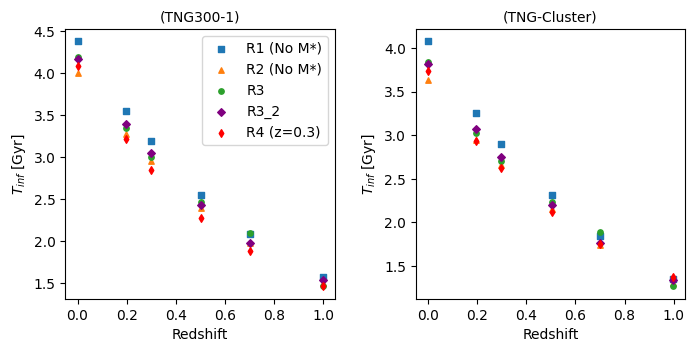

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(8,3.5))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
ax = axes.flatten()

for i, key in enumerate(r.keys()):
    plot_redshifts = []
    estimates1 = []
    estimates2 = []
    estimates3 = []
    estimates3_2 = []
    estimates4 = []

    for j, snapshot in enumerate(snapshots):
        medianr = np.median(r_clean[key][snapshot])
        medianv = np.median(v_clean[key][snapshot])
        medianm = np.median(logms_clean[key][snapshot])
        Xvect = [medianr, medianv, medianm]

        predicted_T_1 = eqn1noMPlot(Xvect, redshifts[j])
        predicted_T_2 = eqn2noMPlot(Xvect, redshifts[j])
        predicted_T_3 = eqn3Plot(Xvect, redshifts[j])
        predicted_T_3_2 = eqn3_2Plot(Xvect, redshifts[j])
        predicted_T_4 = testz78Plot(Xvect, redshifts[j])
        plot_redshifts.append(redshifts[j])
        estimates1.append(predicted_T_1)
        estimates2.append(predicted_T_2)
        estimates3.append(predicted_T_3)
        estimates3_2.append(predicted_T_3_2)
        estimates4.append(predicted_T_4)
    
    ax[i].scatter(redshifts, estimates1, marker='s', label='R1 (No M*)', s=15)
    ax[i].scatter(redshifts, estimates2, marker='^', label='R2 (No M*)', s=15)
    ax[i].scatter(redshifts, estimates3, marker='o', label='R3', s=15)
    ax[i].scatter(redshifts, estimates3_2, marker='D', label='R3_2', s=15, color='purple')
    ax[i].scatter(redshifts, estimates4, marker='d', label='R4 (z=0.3)', s=15, color='red')
    ax[i].set_xlabel('Redshift')
    ax[i].set_ylabel(r'$T_{inf}$ [Gyr]')
    
ax[0].set_title("(TNG300-1)", fontsize='10')
ax[1].set_title("(TNG-Cluster)", fontsize='10')
# fig.suptitle("Predictions for Median Galaxy at Each Redshift", fontsize='10', y=1.02)
ax[0].legend()


Text(0.5, 0.95, '(TNG300-1)')

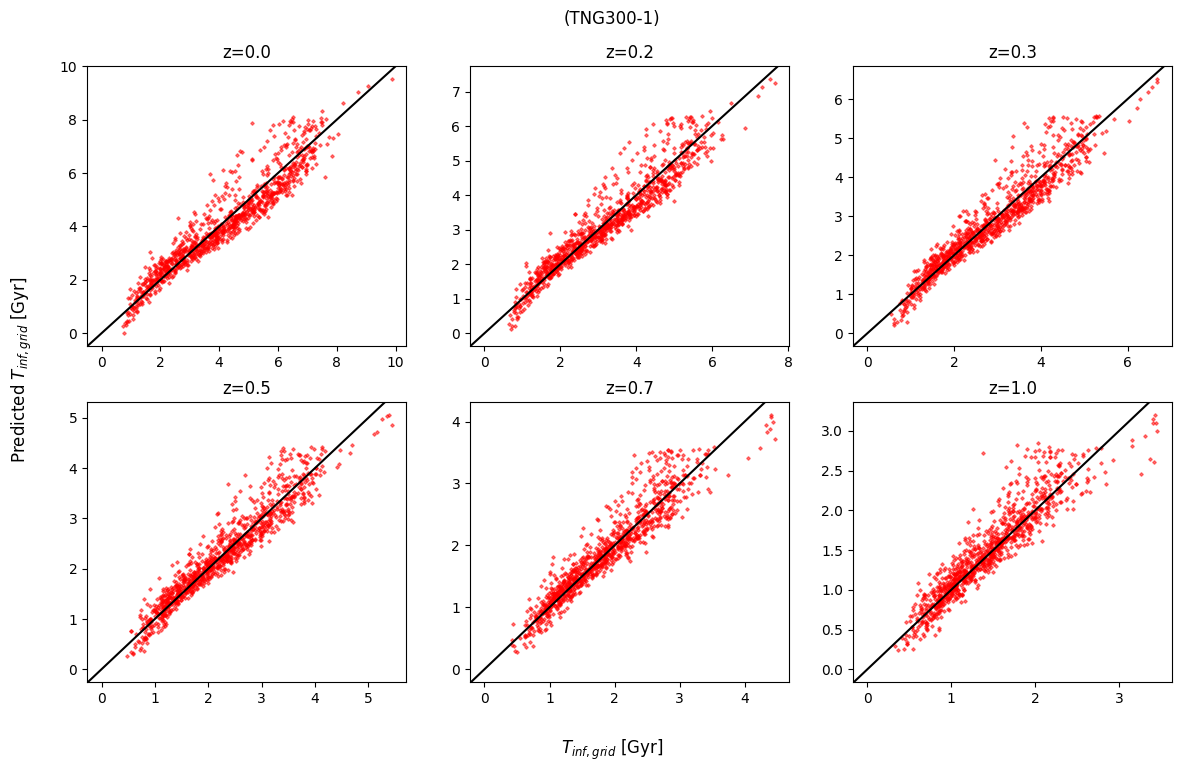

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))
plt.subplots_adjust(hspace=0.2, wspace=0.2)
ax = axes.flatten()

for i in range(6):
    snapshot = snapshots[i]
    ax[i].scatter(y_mean_sep['tng300'][snapshot], testz78Plot(X_binned_sep['tng300'][snapshot].T, redshifts[i]), label='R4 (z=0.3)', marker='D', s=3, color='red', alpha=0.5)
    ax[i].axline((0, 0), slope=1, color='black', label='1:1 Line')
    ax[i].set_title(f"z={round(redshifts[i],2)}")

fig.supxlabel(r"$T_{inf,grid}$ [Gyr]")
fig.supylabel(r"Predicted $T_{inf,grid}$ [Gyr]", x=0.07)
# fig.suptitle(r"Predicted vs True Infall Time for $T_{inf}=Av + \left(B\sqrt{r\cdot\log_{10}(M_{\ast}/M_{\odot})} - C\right)^2$" + "\n(TNG300-1)", linespacing=1.5)
fig.suptitle(r"(TNG300-1)", y=0.95)

# plt.tight_layout()

Text(0.5, 0.95, '(TNG-Cluster)')

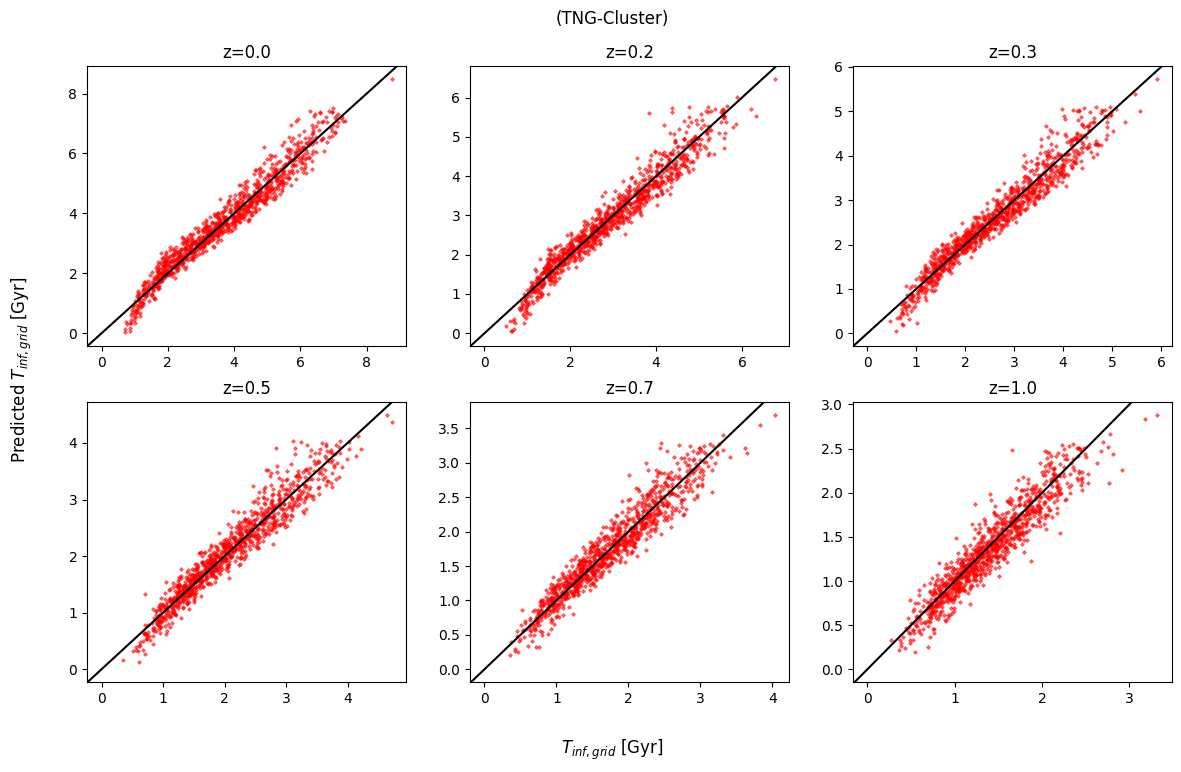

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))
plt.subplots_adjust(hspace=0.2, wspace=0.2)
ax = axes.flatten()

for i in range(6):
    snapshot = snapshots[i]
    ax[i].scatter(y_mean_sep['cluster'][snapshot], testz78Plot(X_binned_sep['cluster'][snapshot].T, redshifts[i]), label='R4 (z=0.3)', marker='D', s=3, color='red', alpha=0.5)
    ax[i].axline((0, 0), slope=1, color='black', label='1:1 Line')
    ax[i].set_title(f"z={round(redshifts[i],2)}")

fig.supxlabel(r"$T_{inf,grid}$ [Gyr]")
fig.supylabel(r"Predicted $T_{inf,grid}$ [Gyr]", x=0.07)
# fig.suptitle(r"Predicted vs True Infall Time for $T_{inf}=Av + \left(B\sqrt{r\cdot\log_{10}(M_{\ast}/M_{\odot})} - C\right)^2$" + "\n(TNG-Cluster)", linespacing=1.5)
fig.suptitle(r"(TNG-Cluster)", y=0.95)

# plt.tight_layout()

In [40]:
rmse4 = {'tng300': {}, 'cluster': {}}
for key in r.keys():
    rmse4[key] = []
    for i, snapshot in enumerate(snapshots):
        redshift = redshifts[i]
        r_raw = r_clean[key][snapshot]
        v_raw = np.abs(v_clean[key][snapshot])
        m_raw = logms_clean[key][snapshot]
        y_clean = T_inf1_clean[key][snapshot]
        
        X_clean = np.column_stack((r_raw, v_raw, m_raw))
        
        pred1 = eqn1noMPlot(X_clean.T, redshift)
        pred2 = eqn2noMPlot(X_clean.T, redshift)
        pred3 = eqn3Plot(X_clean.T, redshift)
        pred3_2 = eqn3_2Plot(X_clean.T, redshift)
        pred4 = testz78Plot(X_clean.T, redshift)

        rmse1 = np.sqrt(mean_squared_error(y_clean, pred1))
        rmse2 = np.sqrt(mean_squared_error(y_clean, pred2))
        rmse3 = np.sqrt(mean_squared_error(y_clean, pred3))
        rmse3_2 = np.sqrt(mean_squared_error(y_clean, pred3_2))
        rmse4[key].append(np.sqrt(mean_squared_error(y_clean, pred4)))

        print(f"RMSEs at redshift: {round(redshift,2)} | Mean infall time at this redshift: {np.mean((y_clean))}")
        print(f"    Eqn1: {round(rmse1,2)}\n    Eqn2: {round(rmse2,2)}\n    Eqn3: {round(rmse3,2)}\n    Eqn3_2: {round(rmse3_2,2)}\n    Eqn4: {round(rmse4[key][i],2)}")

RMSEs at redshift: 0.0 | Mean infall time at this redshift: 4.272046945748905
    Eqn1: 2.75
    Eqn2: 2.65
    Eqn3: 2.64
    Eqn3_2: 2.63
    Eqn4: 2.63
RMSEs at redshift: 0.2 | Mean infall time at this redshift: 3.3395402779696606
    Eqn1: 2.11
    Eqn2: 2.06
    Eqn3: 2.05
    Eqn3_2: 2.05
    Eqn4: 2.04
RMSEs at redshift: 0.3 | Mean infall time at this redshift: 2.959515066060044
    Eqn1: 1.88
    Eqn2: 1.85
    Eqn3: 1.84
    Eqn3_2: 1.83
    Eqn4: 1.81
RMSEs at redshift: 0.5 | Mean infall time at this redshift: 2.3516645750226983
    Eqn1: 1.54
    Eqn2: 1.52
    Eqn3: 1.52
    Eqn3_2: 1.52
    Eqn4: 1.46
RMSEs at redshift: 0.7 | Mean infall time at this redshift: 1.9489394550634476
    Eqn1: 1.33
    Eqn2: 1.32
    Eqn3: 1.32
    Eqn3_2: 1.31
    Eqn4: 1.21
RMSEs at redshift: 1.0 | Mean infall time at this redshift: 1.509280111337082
    Eqn1: 1.1
    Eqn2: 1.09
    Eqn3: 1.08
    Eqn3_2: 1.09
    Eqn4: 0.93
RMSEs at redshift: 0.0 | Mean infall time at this redshift: 3.664484

In [41]:
# fit eqn for RMSE across redshift
poptRMSE = {'tng300': {}, 'cluster': {}}
pcovRMSE = {'tng300': {}, 'cluster': {}}
for key in r.keys():
    poptRMSE[key], pcovRMSE[key] = curve_fit(quadFit, redshifts, rmse4[key], p0 = [1.0, 1.0, 1.0], nan_policy='omit')
    print(f"Mean RMSE evolution with redshift: {round(poptRMSE[key][0],3)}z^2 + {round(poptRMSE[key][1],3)}z + {round(poptRMSE[key][2],3)}")

Mean RMSE evolution with redshift: 1.28z^2 + -2.941z + 2.603
Mean RMSE evolution with redshift: 1.152z^2 + -2.738z + 2.569


Text(0.5, 1.0, '(TNG-Cluster)')

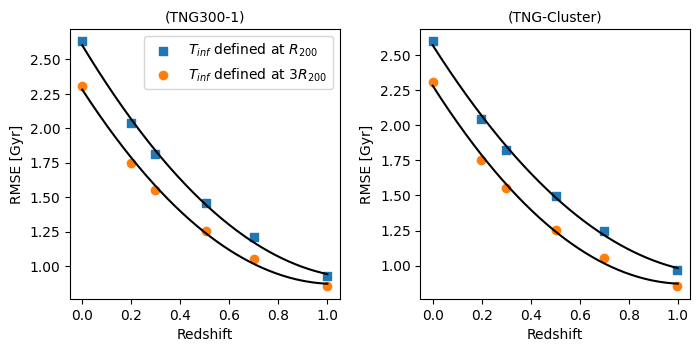

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(8,3.5))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
ax = axes.flatten()

for i, key in enumerate(r.keys()):
    ax[i].scatter(redshifts, rmse4[key], marker='s', label='$T_{inf}$ defined at $R_{200}$')
    ax[i].scatter(redshifts, rmseF, label='$T_{inf}$ defined at $3R_{200}$')
    vals = np.linspace(0,1,300)
    rmseEqn = poptRMSE[key][0]*vals**2 + poptRMSE[key][1]*vals + poptRMSE[key][2]
    ax[i].plot(vals, rmseEqn, color='black')
    valsF = np.linspace(0,1,300)
    rmseFEqn = 1.328*valsF**2 - 2.737*valsF + 2.281
    ax[i].plot(valsF, rmseFEqn, color='black') 
    ax[i].set_xlabel("Redshift")
    ax[i].set_ylabel("RMSE [Gyr]")

# fig.suptitle("Mean RMSE Evolution with Redshift", fontsize='10', y=1.02)
ax[0].legend()
ax[0].set_title("(TNG300-1)", fontsize=10)
ax[1].set_title("(TNG-Cluster)", fontsize=10)

Text(0.5, 0.98, '(TNG300-1)')

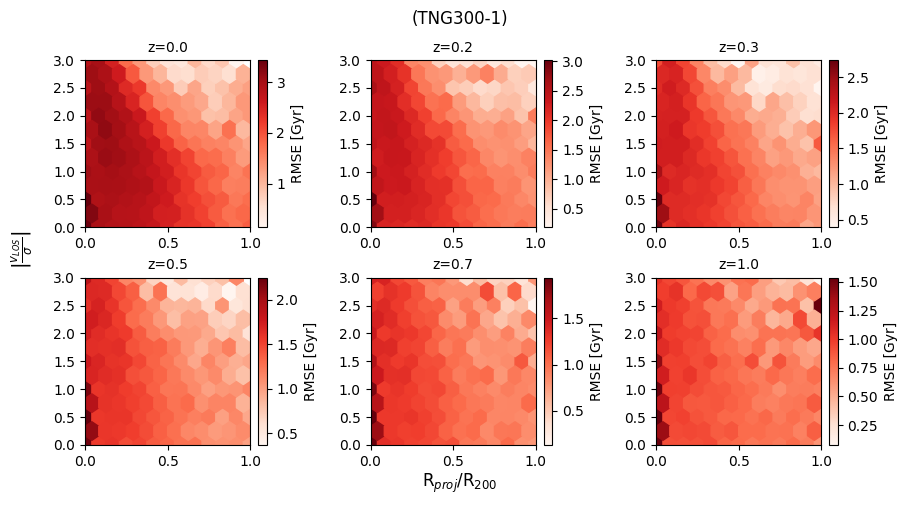

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(10,5))
plt.subplots_adjust(hspace=0.3, wspace=0.4)
ax = axes.flatten()

for i in range(6):
    snapshot = snapshots[i]
    redshift = redshifts[i]
    
    r_raw = r_clean['tng300'][snapshot]
    v_raw = np.abs(v_clean['tng300'][snapshot])
    m_raw = logms_clean['tng300'][snapshot]
    y_clean = T_inf1_clean['tng300'][snapshot]
    
    X_clean = np.column_stack((r_raw, v_raw, m_raw))
    y_pred = testz78Plot(X_clean.T, redshift)
    r_plot = X_clean[:, 0]  
    v_plot = X_clean[:, 1]

    sq_errors = (y_clean - y_pred) ** 2

    ax[i].set_title(f"z={round(redshift,1)}", fontsize=10)
    hb = ax[i].hexbin(r_plot, v_plot, C=sq_errors, reduce_C_function=lambda cell: np.sqrt(np.mean(cell)), gridsize=12, extent=[0,1,0,3], cmap='Reds') # , vmin=0 , vmax=3.5)
    ax[i].set_xlim(0,1)
    ax[i].set_ylim(0,3)
    fig.colorbar(hb, ax=ax[i], pad=0.04, label='RMSE [Gyr]')

fig.supxlabel('R$_{proj}$/R$_{200}$') #, x=0.45, y=0.01)
fig.supylabel(r'$\left| \frac{v_{LOS}}{\sigma} \right|$', x=0.05)
# fig.suptitle('RMSE Estimates Across PPS at Different Redshifts\n(TNG300-1)', y=1.02) #, x=0.45)
fig.suptitle('(TNG300-1)') #, x=0.45)
# plt.tight_layout()

Text(0.5, 0.98, '(TNG-Cluster)')

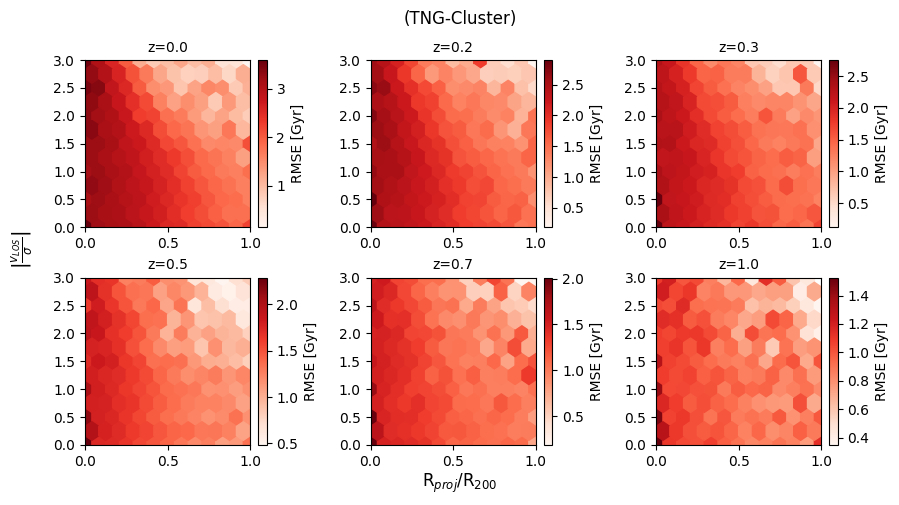

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(10,5))
plt.subplots_adjust(hspace=0.3, wspace=0.4)
ax = axes.flatten()

for i in range(6):
    snapshot = snapshots[i]
    redshift = redshifts[i]
    
    r_raw = r_clean['cluster'][snapshot]
    v_raw = np.abs(v_clean['cluster'][snapshot])
    m_raw = logms_clean['cluster'][snapshot]
    y_clean = T_inf1_clean['cluster'][snapshot]
    
    X_clean = np.column_stack((r_raw, v_raw, m_raw))
    y_pred = testz78Plot(X_clean.T, redshift)
    r_plot = X_clean[:, 0]  
    v_plot = X_clean[:, 1]

    sq_errors = (y_clean - y_pred) ** 2

    ax[i].set_title(f"z={round(redshift,1)}", fontsize=10)
    hb = ax[i].hexbin(r_plot, v_plot, C=sq_errors, reduce_C_function=lambda cell: np.sqrt(np.mean(cell)), gridsize=12, extent=[0,1,0,3], cmap='Reds') # , vmin=0 , vmax=3.5)
    ax[i].set_xlim(0,1)
    ax[i].set_ylim(0,3)
    fig.colorbar(hb, ax=ax[i], pad=0.04, label='RMSE [Gyr]')

fig.supxlabel('R$_{proj}$/R$_{200}$') #, x=0.45, y=0.01)
fig.supylabel(r'$\left| \frac{v_{LOS}}{\sigma} \right|$', x=0.05)
# fig.suptitle('RMSE Estimates Across PPS at Different Redshifts\n(TNG-Cluster)', y=1.02) #, x=0.45)
fig.suptitle('(TNG-Cluster)') #, x=0.45)

Functional forms of the two means

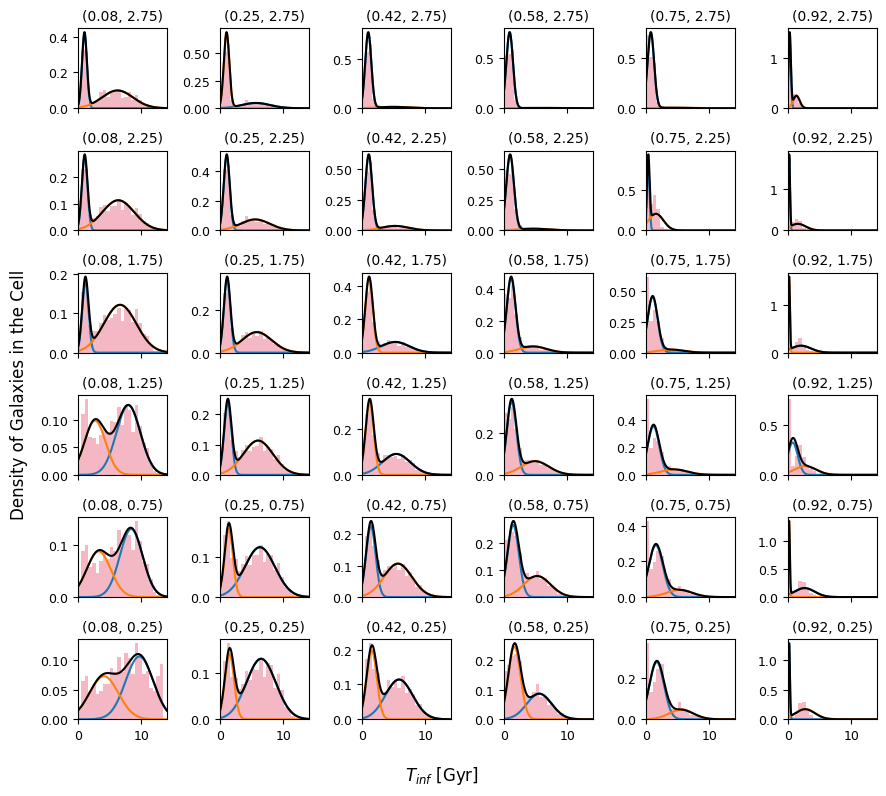

In [45]:
# coarse grid example of T_inf distribution

# infall distributions defined at R200
t_inf = infall_axis1_clean[99]
r_vals = r_axis_clean[99]
v_vals = np.abs(v_axis_clean[99])

# store means for PySR 
all_means = []

# grid bins
r_edges = np.linspace(0.0, 1.0, 7)  
v_edges = np.linspace(0.0, 3.0, 7)  

n_bins_x = len(r_edges) - 1
n_bins_y = len(v_edges) - 1

fig, axes = plt.subplots(n_bins_y, n_bins_x, figsize=(9, 8), sharex=True, sharey=False) # sharex parameter makes all table share same x axis
# plt.subplots_adjust(hspace=0.8, wspace=0.3) # this makes padding
# fig.suptitle(r"Distributions of Infall Times Defined at $R_{200}$")
fig.supxlabel(r"$T_{inf}$ [Gyr]")
fig.supylabel("Density of Galaxies in the Cell")
# x axis array for curve fit
t_plot = np.linspace(0, 14, 300)

# loop over rows
for row in range(n_bins_y):
    # make velocity indexing start at bottom
    v_idx = n_bins_y - 1 - row
    v_low, v_high = v_edges[v_idx], v_edges[v_idx + 1]
    v_center = (v_low + v_high) / 2 # define bin centre
    
    # loop over columns 
    for col in range(n_bins_x):
        r_low, r_high = r_edges[col], r_edges[col + 1]
        r_center = (r_low + r_high) / 2 # define bin centre
        
        ax = axes[row, col]

        cell_mask = (r_vals >= r_low) & (r_vals < r_high) & (v_vals >= v_low) & (v_vals < v_high)
        t_cell = t_inf[cell_mask]
        
        ax.set_title(f"({r_center:.2f}, {v_center:.2f})", fontsize=10)
    
        ax.hist(t_cell, bins=25, range=(0, 14), density=True, alpha=0.3, color='crimson', edgecolor='none')
        
        gmm = GaussianMixture(n_components=2, random_state=42)
        gmm.fit(t_cell.reshape(-1, 1))
        
        # get parameters of gaussian components generated to sum
        weights = gmm.weights_
        means = gmm.means_.flatten()
        covariances = gmm.covariances_.flatten()
        stddevs = np.sqrt(covariances)
        
        all_means.append(means)

        total_pdf = np.zeros_like(t_plot)
        colors = ['#1f77b4', '#ff7f0e'] 
        
        for k in range(2):
            component_pdf = weights[k] * norm.pdf(t_plot, means[k], stddevs[k])
            total_pdf += component_pdf
            
            ax.plot(t_plot, component_pdf, color=colors[k], lw=1.5)
            
        ax.plot(t_plot, total_pdf, color='black', lw=1.5)
        
        ax.tick_params(axis='both', labelsize=9)
        ax.set_xlim(0, 14)

        

plt.tight_layout()
plt.show()

In [46]:
# BIN CODE AGAIN TO REDEFINE WEIGHTS, OR RUN CELL 7 AGAIN BEFORE MODEL FIT
X_binned = {}
y_mean = {}
y_q1 = {}
y_med = {}
y_q3 = {}

for snapshot in snapshots:
    # prepare all raw inputs as a matrix with columns of each input
    X_clean = np.column_stack((r_axis_clean[snapshot], np.abs(v_axis_clean[snapshot]), m_axis_clean[snapshot])) #, log10vir[snapshot]))
    y_clean = infall_axis1_clean[snapshot]

    # X_clean[np.isinf(X_raw)] = np.nan

    # clean_rows = ~np.isnan(X_raw).any(axis=1) & ~np.isnan(y_raw)

    # X_clean = X_raw[clean_rows]
    # y_clean = y_raw[clean_rows]
    # create percentile bins

    r_edges = np.percentile(X_clean[:,0], np.linspace(0, 100, 21))
    v_edges = np.percentile(X_clean[:,1], np.linspace(0, 100, 21))
    m_edges = np.percentile(X_clean[:,2], np.linspace(0, 100, 7))
    # vir_edges = np.percentile(X_clean[:,3], np.linspace(0, 100, 5))

    quartile_bins = [r_edges, v_edges, m_edges] #, vir_edges]
    # sort data into bins

    # compute num of galaxies in each bin
    counts, _, _ = binned_statistic_dd(
        X_clean, values=None, statistic='count', bins=quartile_bins
    )

    # mask for only filled bins
    filled = np.where(counts > 0)
    Ngal_per = counts[filled]
    weights = np.log10(Ngal_per + 10)

    # extract mean features for grid size
    binned = []
    for i in range(X_clean.shape[1]):
        means, _, _ = binned_statistic_dd(X_clean, values=X_clean[:,i], statistic='mean', bins=quartile_bins)
        binned.append(means[filled])
    X_binned[snapshot] = np.column_stack(binned)

    mean_y, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic='mean', bins=quartile_bins)
    y_mean[snapshot] = mean_y[filled]

    q1_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 25), bins=quartile_bins)
    y_q1[snapshot] = q1_y_grid[filled]

    q2_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 50), bins=quartile_bins)
    y_med[snapshot] = q2_y_grid[filled]

    q3_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 75), bins=quartile_bins)
    y_q3[snapshot] = q3_y_grid[filled]

    print(f"Num of binned data points for PySR: {len(y_mean[snapshot])}")
    # mask for valid entries in bins
    mean_mask = ~np.isnan(y_mean[snapshot]) & (y_mean[snapshot] > 0)
    q1_mask = ~np.isnan(y_q1[snapshot]) & (y_q1[snapshot] > 0)
    med_mask = ~np.isnan(y_med[snapshot]) & (y_med[snapshot] > 0)
    q3_mask = ~np.isnan(y_q3[snapshot]) & (y_q3[snapshot] > 0)

    y_mean[snapshot] = y_mean[snapshot][mean_mask]
    y_q1[snapshot] = y_q1[snapshot][q1_mask]
    y_med[snapshot] = y_med[snapshot][med_mask]
    y_q3[snapshot] = y_q3[snapshot][q3_mask]

    # use if want to fit in log M* or log 10^10 M*
    # X_binned[snapshot][:,2] = X_binned[snapshot][:,2]-10
    # X_binned[snapshot][:,3] = X_binned[snapshot][:,3]-10

Num of binned data points for PySR: 2400
Num of binned data points for PySR: 2400
Num of binned data points for PySR: 2400
Num of binned data points for PySR: 2400
Num of binned data points for PySR: 2400
Num of binned data points for PySR: 2396


In [47]:
# bin again for finer grid to fit with pySR

t_inf = infall_axis1_clean[99]
r_vals = r_axis_clean[99]
v_vals = np.abs(v_axis_clean[99])
ms_vals = m_axis_clean[99] 

r_edges = np.linspace(0.0, 1.0, 12)   
v_edges = np.linspace(0.0, 3.0, 12)  
log_M_edges = np.linspace(9.0, ms_vals.max(), 9) 

n_bins_x = len(r_edges) - 1
n_bins_y = len(v_edges) - 1
n_bins_z = len(log_M_edges) - 1

# lists for pySR array storage
X_pysr_list = []
y1_list = []
y2_list = []

for i in range(n_bins_x):
    r_low, r_high = r_edges[i], r_edges[i + 1]
    r_center = (r_low + r_high) / 2
    
    for j in range(n_bins_y):
        v_low, v_high = v_edges[j], v_edges[j + 1]
        v_center = (v_low + v_high) / 2
        
        for k in range(n_bins_z):
            log_M_low, log_M_high = log_M_edges[k], log_M_edges[k + 1]
            log_M_center = (log_M_low + log_M_high) / 2
            
            # Apply your exact cell masking strategy inside 3D space
            cell_mask = (
                (r_vals >= r_low) & (r_vals < r_high) &
                (v_vals >= v_low) & (v_vals < v_high) &
                (ms_vals >= log_M_low) & (ms_vals < log_M_high)
            )
            t_cell = t_inf[cell_mask]

            try:
                gmm = GaussianMixture(n_components=2, random_state=42)
                gmm.fit(t_cell.reshape(-1, 1))
                
                means_sorted = np.sort(gmm.means_.flatten())
                
                X_pysr_list.append([r_center, v_center, log_M_center])
                y1_list.append(means_sorted[0]) 
                y2_list.append(means_sorted[1]) 
            except ValueError:
                # Catch any unexpected optimization/matrix math edge cases
                continue
                
X_input = np.array(X_pysr_list)
X_input[:,2] = X_input[:,2] - 10
mean1 = np.array(y1_list)
mean2 = np.array(y2_list)

c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly du

In [48]:
# # assign mean values to each galaxy that it belongs in 

# T_mean1 = [min(array) for array in all_means]
# T_mean2 = [max(array) for array in all_means]

# T_mean1_arr = np.array(T_mean1)
# T_mean2_arr = np.array(T_mean2)

# gal_r = X_binned[99][:,0]
# gal_v = np.abs(X_binned[99][:,1]) 

# r_bins = np.digitize(gal_r, r_edges) - 1
# r_bins = np.clip(r_bins, 0, n_bins_x - 1)

# v_bins = np.digitize(gal_v, v_edges) - 1
# v_bins = np.clip(v_bins, 0, n_bins_y - 1)

# row_indices = (n_bins_y - 1) - v_bins  
# col_indices = r_bins

# flat_indices = row_indices * n_bins_x + col_indices

# assignedMean1, assignedMean2 = T_mean1_arr[flat_indices], T_mean2_arr[flat_indices]

# print("Assigned shape:", assignedMean1[:].shape)
# print(assignedMean1[:])

In [49]:
model = PySRRegressor(
    #elementwise_loss="loss(x, y) = abs(x - y)",
    niterations=1000,
    binary_operators=["+", "-", "*", "/", "^"],
    #binary_operators=["+", "-", "*", "^"],
    #unary_operators=["exp", "sqrt", "square", "cos"],
    unary_operators=["exp", "sqrt", "square", 'log'],
    procs=4,
    maxsize=25,       # Limits the size of expressions
    #maxdepth=20,
    populations=25,
    model_selection="best",
    constraints={ 'exp':3, '^': (-1, 0)}
)

In [50]:
# model.fit(X_input, mean1, variable_names=["r", "v", "logms"])

In [51]:
for idx in range(len(model.equations_)):
        complexity = model.equations_.iloc[idx]['complexity']

        eqn_sympy = model.sympy(idx)
        
        # round to 3 decimals
        clean_eqn = eqn_sympy.atoms(sp.Float)
        mapping = {num: round(float(num), 3) for num in clean_eqn}
        final_eqn = eqn_sympy.subs(mapping)

        print(f"{final_eqn}")

AttributeError: 'PySRRegressor' object has no attribute 'equations_'

In [ ]:
# model.fit(X_input, mean2, variable_names=["r", "v", "logms"])

c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\pysr\sr.py:2217: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.490e+05
Progress: 1399 / 25000 total iterations (5.596%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.651e+00  0.000e+00  y = 4.7973
3           4.852e+00  7.627e-02  y = 5.2804 - r
4           3.232e+00  4.062e-01  y = exp(2.0236 - r)
6           2.745e+00  8.172e-02  y = exp(2.2638 - r) - v
8           2.658e+00  1.603e-02  y = (exp(2.32 - r) - v) - logms
9           2.465e+00  7.567e-02  y = (8.929 - v) + (r * (-5.0315 - logms))
10          2.428e+00  1.488e-02  y = ((logms * -0.58405) + exp(2.32 - r)) - v
12          2.388e+00  8.309e-03  y = (((logms * -0.60426) + 0.75054) + exp(2.2095 - r)) - v
14          2.386e+00  4.861e-04  y = (((logms * -0.6026) + (exp(2.3693 - r) - v)) + r) - 0....
                                      74728
15

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '-', ...]"
,unary_operators,"['exp', 'sqrt', ...]"
,expression_spec,None
,niterations,1000
,populations,25
,population_size,27
,max_evals,None
,maxsize,25
,maxdepth,None
,warmup_maxsize_by,None


  - outputs\20260708_114033_vBn9ey\hall_of_fame.csv


In [ ]:
for idx in range(len(model.equations_)):
        complexity = model.equations_.iloc[idx]['complexity']

        eqn_sympy = model.sympy(idx)
        
        # round to 3 decimals
        clean_eqn = eqn_sympy.atoms(sp.Float)
        mapping = {num: round(float(num), 3) for num in clean_eqn}
        final_eqn = eqn_sympy.subs(mapping)

        print(f"{final_eqn}")

4.79700000000000
5.28 - r
7.56853862048531*exp(-r)
4.149/(r + 0.471)
-v + 9.62149829046669*exp(-r)
-v + 6.847/(r + 0.69)
-logms - v + 10.5697907173176*exp(-r)
r*(-logms - 5.031) - v + 8.929
sqrt(r)*(-logms - 6.529) - v + 10.894
0.913*sqrt(r)*(-logms - 7.186) - 0.913*v + 10.756
sqrt(r)*(-exp(0.582*logms) - 5.516) - v + 10.919
0.652*sqrt(r)*(-logms*v - 10.23) - 0.652*v + 10.409
0.809*sqrt(r)*(-logms*sqrt(v) - 8.198) - 0.809*v + 10.621
-0.203*v*(exp(logms) + exp(r)) - 1.734*log(r) + 4.274
-2.92*r + v*(-0.189*exp(logms) - 0.442) - log(r) + 6.519
-1.488*r**2 + 1.488*v*(-0.126*exp(logms) - 0.297) - 1.488*log(r) + 5.078
-1.581*r**4 - 0.187*v*(exp(logms) + 2.361) - 1.581*log(r) + 4.807
-1.25*r**2 - 0.15*(r + v)*(exp(logms) + 3.761) - 1.25*log(r) + 5.756
-1.33*r**4 + 1.33*(-0.113*r - 0.113*v)*(exp(logms) + 3.734) - 1.33*log(r) + 5.521
-1.328*r**4 + 1.328*(exp(logms) + 2.554)*(-0.138*r - 0.138*v + 0.046) - 1.328*log(r) + 5.167
-1.358*r**5 + 1.358*(-0.134*exp(logms) - 0.346)*(r + v - 0.33) - 1.35

In [ ]:
mean1Fit = PySRRegressor.from_file(run_directory=r"C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\mean1Fit")
mean2Fit = PySRRegressor.from_file(run_directory=r"C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\mean2Fit")

model_names = ["mean1Fit", "mean2Fit"]
models = [mean1Fit, mean2Fit]

for i, model in enumerate(models):
    print("-" * 80)
    print(f"All discovered eqns for {model_names[i]}")
    print("-" * 80)
    for idx in range(len(model.equations_)):
        # complexity = model.equations_.iloc[idx]['complexity']

        eqn_sympy = model.sympy(idx)
        
        # round to 3 decimals
        clean_eqn = eqn_sympy.atoms(sp.Float)
        mapping = {num: round(float(num), 3) for num in clean_eqn}
        final_eqn = eqn_sympy.subs(mapping)

        print(f"{final_eqn}")

Attempting to load model from C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\mean1Fit\checkpoint.pkl...
Attempting to load model from C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\mean2Fit\checkpoint.pkl...


--------------------------------------------------------------------------------
All discovered eqns for mean1Fit
--------------------------------------------------------------------------------
1.28600000000000
1.769 - r
0.672/sqrt(r)
-0.708/(-r - 0.207)
0.546/sqrt(r*v)
1.211*sqrt(exp(-v)/r)
1.699/(sqrt(r)*(v + 1.389))
0.822/(r + 0.159*v + 0.087)
-0.45 + 7.564/(5.425*sqrt(r) + v)
sqrt(-r + 0.909 + 1.207*exp(-v)/r)
sqrt(-r**2 + 0.842 + 1.163*exp(-v)/r)
((-r**2 + 0.73 + 1.214*exp(-v)/r)**2)**(1/4)
((-r**4 + 0.579 + 1.23*exp(-v)/r)**2)**(1/4)
((-1.184*r**4 + 0.647 + 1.212*exp(-v)/r)**2)**(1/4)
1.196*((0.837 - r**4)/((r - 0.02)*(r + v**2)))**(1/4)
1.674*sqrt((0.688 - r**8)**2/(r*(v + 0.982)**2)) + 0.338
(((r**2 + 0.212)**4 - 1.1 - 1.392*exp(-v)/r)**2)**(1/4) - 0.243
1.439*((0.701 - r**8)/(r*(r + v**2)))**(1/4)
1.692*((r**8 - 0.612)**2/(r*(r + v**2)))**(1/4)
1.747*((0.611 - r**8)**2/(r*(1.348*r + v**2)))**(1/4)
-------------------------------------------------------------------------------

In [ ]:
def mean1Plot(Xvect):
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    # return np.maximum(0, (0.978 - np.log(r - 0.012))*np.exp(-0.353*v))
    return np.maximum(0, -0.477 + 8.273/(5.983*np.sqrt(r) + v))


def mean2Plot(Xvect): 
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    # return np.maximum(0, logms*(-0.648*np.sqrt(r) - 0.183*np.sqrt(v)) + 11.546)
    return np.maximum(0, np.sqrt(r)*(-np.exp(0.582*logms) - 5.516) - v + 10.919)


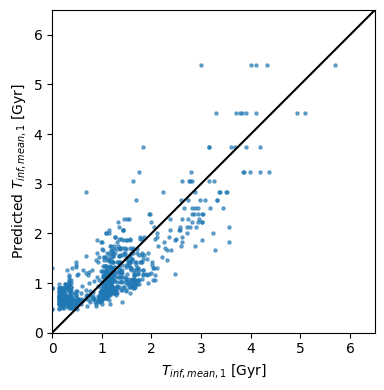

In [ ]:
plt.figure(figsize=(4.0,4.0))
plt.scatter(mean1, mean1Plot(X_input.T), s=5, alpha=0.6)
plt.axline((0, 0), slope=1, color='black', label='1:1 Line')
plt.xlabel(r"$T_{inf,mean, 1}$ [Gyr]")
plt.ylabel(r"Predicted $T_{inf,mean, 1}$ [Gyr]")
plt.axis('square')
plt.xlim(0,6.5)
plt.ylim(0,6.5)
plt.tight_layout()

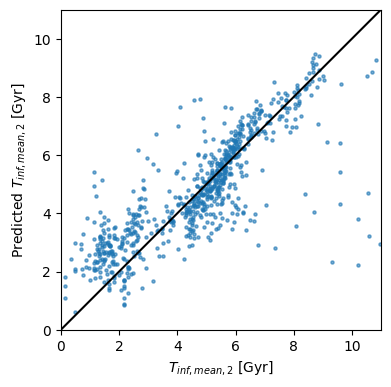

In [ ]:
plt.figure(figsize=(4.0,4.0))
plt.scatter(mean2, mean2Plot(X_input.T), s=5, alpha=0.6)
plt.axline((0, 0), slope=1, color='black', label='1:1 Line')
plt.xlabel(r"$T_{inf,mean, 2}$ [Gyr]")
plt.ylabel(r"Predicted $T_{inf,mean, 2}$ [Gyr]")
plt.axis('square')
plt.xlim(0,11)
plt.ylim(0,11)
plt.tight_layout()